# Macrófagos mordisqueando células vivas

**62,7 %.**

Esa es la fracción de células de pulmón etiquetadas que terminan dentro de **un solo tipo** de macrófago — el macrófago alveolar — sin que la célula original muera. No se las comen enteras: les arrancan vesículas sub-micrométricas y siguen su camino.

> Fan, Thota, Serwas et al. (2026). *Submicrometre sampling of living cells by macrophages*. **Nature**.
> [DOI: 10.1038/s41586-026-10435-5](https://doi.org/10.1038/s41586-026-10435-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-29-macrofagos-trogocitosis-celulas-vivas/notebook.ipynb)

## El sistema inmune necesita probar lo sano

Para no atacar al propio cuerpo, el sistema inmune **muestrea** constantemente lo que hay dentro. La historia clásica decía: las células viejas se mueren (apoptosis) y los macrófagos limpian los restos. Ese reciclaje sería la fuente principal de "antígenos propios".

El equipo de Fan probó otra ruta. Etiquetaron células **vivas y sanas** del pulmón de ratón con una proteína fluorescente (ZsGreen) y midieron cuánto de ese material acababa dentro de cada tipo de célula inmune. La respuesta cambia el modelo: hay un mordisqueo activo de tejido vivo, y un tipo celular se lo lleva casi todo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TIPO_DESTACADO = 'AM'           # Macrófago alveolar (el que captura más)
TIPO_REFERENCIA = 'cMo'         # Monocito clásico (el que captura menos)
FUENTE = 'Fuente: Fan et al. (2026), Nature | Datos: Source Data MOESM7-8'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

uptake = pd.read_csv('datos/uptake_pulmon.csv')
vesiculas = pd.read_csv('datos/tamano_vesiculas.csv')
contacto = pd.read_csv('datos/contacto_celula.csv')

print(f"Uptake pulmón: {len(uptake)} filas, {uptake['mouse_id'].nunique()} ratones, {uptake['cell_type'].nunique()} tipos celulares")
print(f"Vesículas: {len(vesiculas)} medidas")
print(f"Contacto célula-célula: {len(contacto)} mediciones, {contacto['replicate_id'].nunique()} réplicas biológicas")

Uptake pulmón: 35 filas, 5 ratones, 7 tipos celulares
Vesículas: 77 medidas
Contacto célula-célula: 6 mediciones, 3 réplicas biológicas


## Quién se lleva el material

Cuando comparas los 7 tipos de células inmunes del pulmón, no hay reparto.

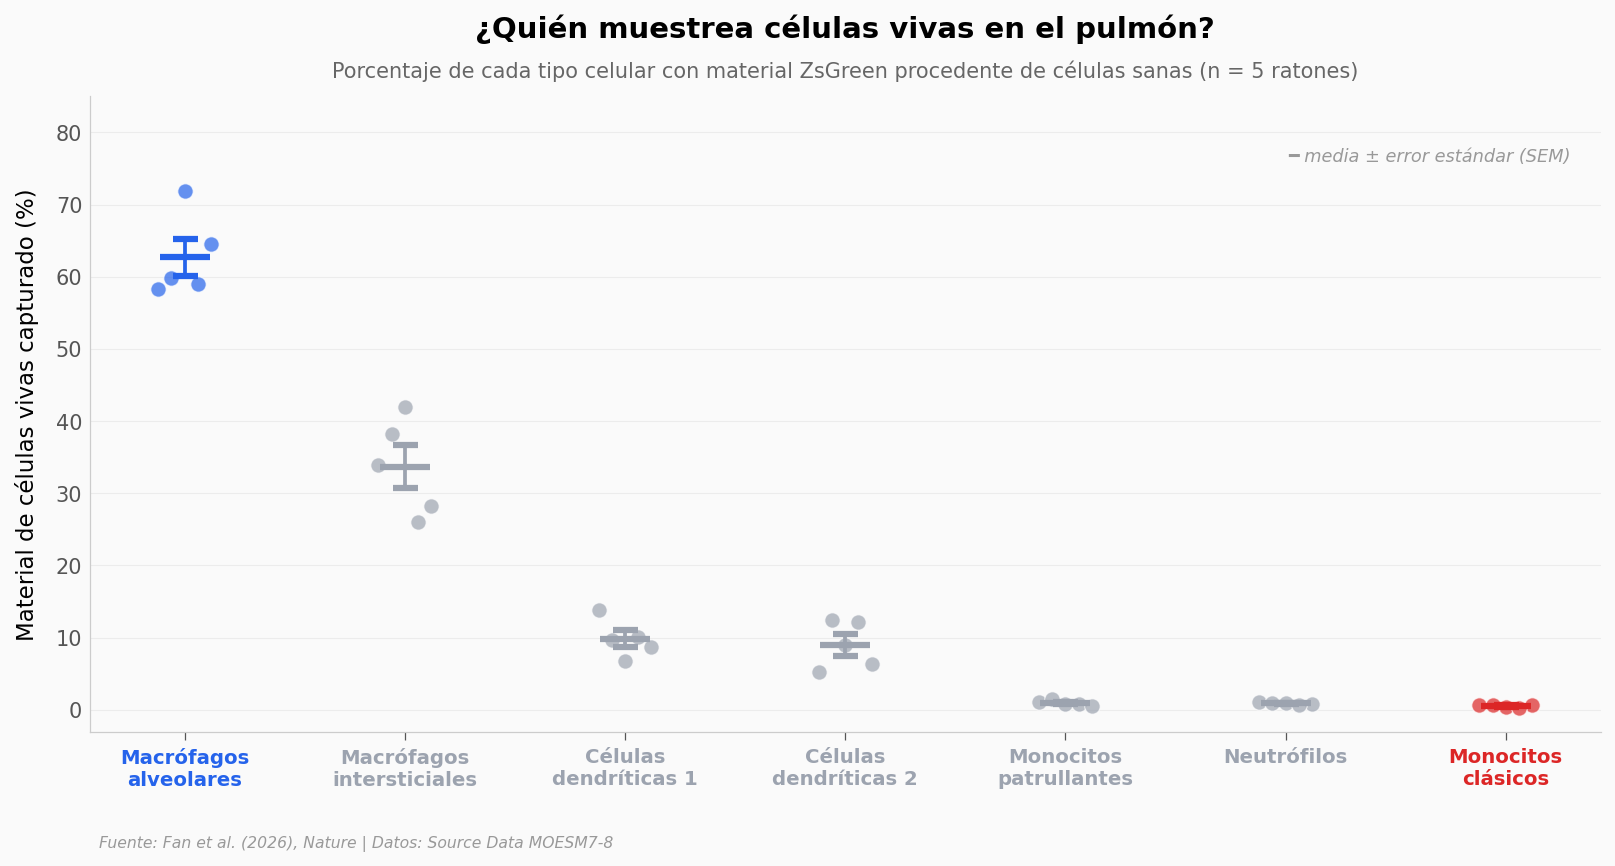

In [2]:
# Orden por uptake medio (descendente) — para que se lea de izquierda a derecha
orden = uptake.groupby('cell_type')['pct_zsgreen_positive'].mean().sort_values(ascending=False).index.tolist()

# Nombres legibles
nombres = {
    'AM':   'Macrófagos\nalveolares',
    'IM':   'Macrófagos\nintersticiales',
    'cDC1': 'Células\ndendríticas 1',
    'cDC2': 'Células\ndendríticas 2',
    'pMo':  'Monocitos\npatrullantes',
    'Neu':  'Neutrófilos',
    'cMo':  'Monocitos\nclásicos',
}

# Colores: AM destacado, resto en gris claro
colores = []
for t in orden:
    if t == TIPO_DESTACADO:
        colores.append(COLOR_DATOS)
    elif t == TIPO_REFERENCIA:
        colores.append(COLOR_ALERTA)
    else:
        colores.append('#9CA3AF')

fig, ax = plt.subplots(figsize=(13, 5.5))

np.random.seed(42)
positions = list(range(len(orden)))
for i, t in enumerate(orden):
    vals = uptake[uptake['cell_type'] == t]['pct_zsgreen_positive'].values
    n = len(vals)
    # Jitter horizontal reproducible
    x_strip = np.linspace(positions[i] - 0.12, positions[i] + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=colores[i], s=55, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=colores[i],
                markersize=24, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

ax.set_xticks(positions)
ax.set_xticklabels([nombres[t] for t in orden], fontsize=9.5, fontweight='bold')
for tick, col in zip(ax.get_xticklabels(), colores):
    tick.set_color(col)

ax.set_ylabel('Material de células vivas capturado (%)', fontsize=11)
ax.set_title('¿Quién muestrea células vivas en el pulmón?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Porcentaje de cada tipo celular con material ZsGreen procedente de células sanas (n = 5 ratones)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.92, '━ media ± error estándar (SEM)', transform=ax.transAxes,
        fontsize=8.5, color='#999999', ha='right', va='top', style='italic')
ax.set_ylim(-3, 85)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/uptake_por_tipo.png', dpi=200, bbox_inches='tight')
plt.show()

**Dos órdenes de magnitud separan al primero del último.** Los macrófagos alveolares se llevan la mayoría del material — el resto orbita entre el 0,5 % y el 35 %. Los monocitos clásicos, que circulan por la sangre y entran al pulmón cuando hay inflamación, casi no participan en este muestreo basal.

Que la diferencia sea de más de 100× con n = 5 ratones no es un artefacto. Los errores estándar son pequeños frente al rango: cada ratón cuenta la misma historia.

## ¿Cómo de grande es cada mordisco?

Si una célula del pulmón mide unos 10 µm de diámetro (un volumen aproximado de 500 µm³), arrancar fragmentos sin matarla obliga a que esos fragmentos sean diminutos. ¿Cuánto?

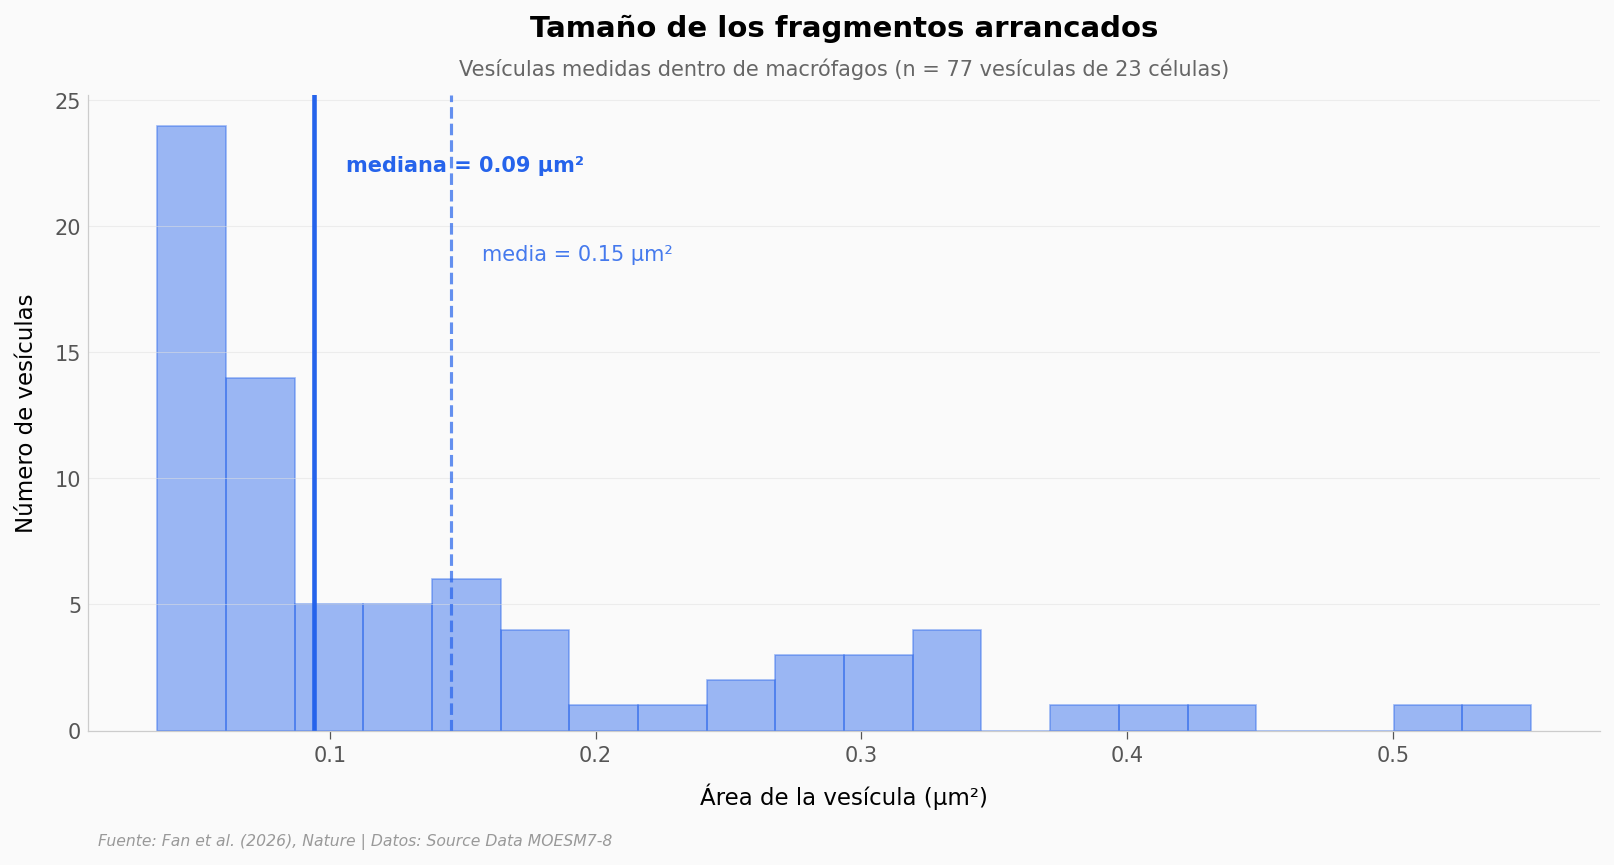

Rango: 0.035 – 0.552 µm²
Diámetro estimado a partir de la mediana: ~0.35 µm


In [3]:
areas = vesiculas['area_um2'].values
mean_area = areas.mean()
median_area = np.median(areas)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.hist(areas, bins=20, color=COLOR_DATOS, alpha=0.45,
        edgecolor=COLOR_DATOS, linewidth=0.8)

ax.axvline(median_area, color=COLOR_DATOS, linewidth=2.2, linestyle='-')
ax.axvline(mean_area, color=COLOR_DATOS, linewidth=1.5, linestyle='--', alpha=0.7)

ax.text(median_area + 0.012, ax.get_ylim()[1]*0.88, f'mediana = {median_area:.2f} µm²',
        fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.text(mean_area + 0.012, ax.get_ylim()[1]*0.74, f'media = {mean_area:.2f} µm²',
        fontsize=10, color=COLOR_DATOS, alpha=0.85)

ax.set_xlabel('Área de la vesícula (µm²)', fontsize=11)
ax.set_ylabel('Número de vesículas', fontsize=11)
ax.set_title('Tamaño de los fragmentos arrancados',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Vesículas medidas dentro de macrófagos (n = {len(areas)} vesículas de 23 células)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tamano_vesiculas.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Rango: {areas.min():.3f} – {areas.max():.3f} µm²")
print(f"Diámetro estimado a partir de la mediana: ~{2*np.sqrt(median_area/np.pi):.2f} µm")

La distribución está sesgada hacia lo pequeño: la **mediana es de 0,09 µm²** (un diámetro estimado de unos 0,3 µm) y todas las vesículas caben por debajo de 0,6 µm². Es el tamaño de una bacteria pequeña, no de una célula.

Que sean sub-micrométricas importa: el macrófago no engulle células enteras, "muerde" trozos del tamaño justo para tomar muestra del contenido — citoplasma, fragmentos de membrana — sin destruir a la otra célula.

## ¿Hace falta tocarse?

Si el muestreo es un mordisco, los macrófagos tienen que **tocar** a la célula objetivo. El equipo separó las dos poblaciones con una membrana porosa (transwell): el medio cultivado fluye libre, pero las células no pueden contactarse.

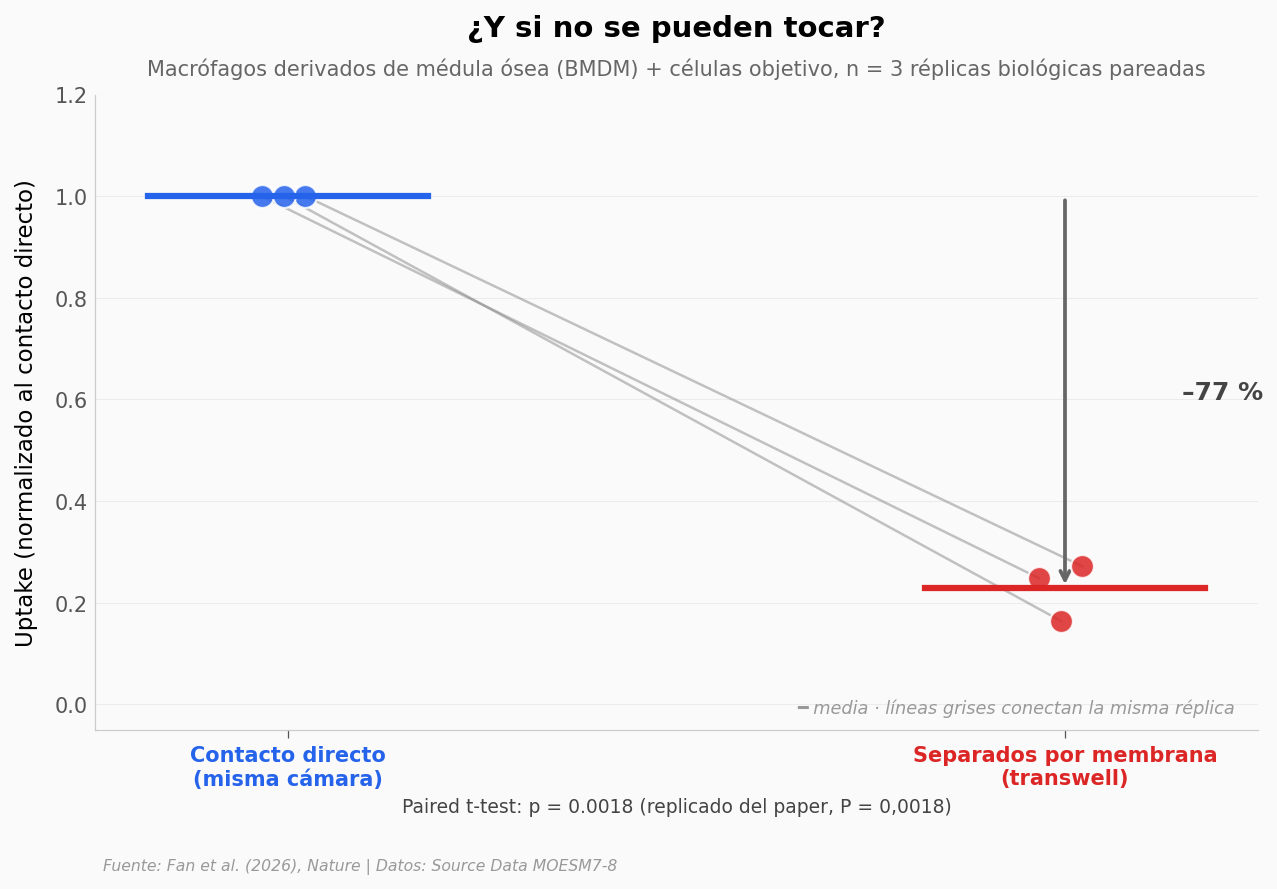

Direct: 1.000 (todas las réplicas normalizadas a 1,0)
Transwell: media = 0.228, reducción = 77.2 %
Paired t-test: t = 23.55, p = 0.0018, n = 3 réplicas


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

direct_vals = contacto[contacto['condition'] == 'direct'].sort_values('replicate_id')['uptake_normalizado'].values
trans_vals = contacto[contacto['condition'] == 'transwell'].sort_values('replicate_id')['uptake_normalizado'].values
replicates = contacto['replicate_id'].unique()
replicates.sort()

x_direct = 0
x_trans = 1
np.random.seed(7)
jitter = np.random.uniform(-0.04, 0.04, len(replicates))

# Líneas pareadas
for i, rep in enumerate(replicates):
    ax.plot([x_direct + jitter[i], x_trans + jitter[i]],
            [direct_vals[i], trans_vals[i]],
            color='#888888', alpha=0.5, linewidth=1.2, zorder=3)

# Puntos
ax.scatter([x_direct + j for j in jitter], direct_vals,
           color=COLOR_DATOS, s=120, alpha=0.85, edgecolors='white',
           linewidths=1.0, zorder=5, label=None)
ax.scatter([x_trans + j for j in jitter], trans_vals,
           color=COLOR_ALERTA, s=120, alpha=0.85, edgecolors='white',
           linewidths=1.0, zorder=5)

# Medias como barra horizontal
ax.plot([x_direct - 0.18, x_direct + 0.18], [direct_vals.mean()] * 2,
        color=COLOR_DATOS, linewidth=3, zorder=6)
ax.plot([x_trans - 0.18, x_trans + 0.18], [trans_vals.mean()] * 2,
        color=COLOR_ALERTA, linewidth=3, zorder=6)

# Anotación de reducción
reduccion = (1 - trans_vals.mean()) * 100
ax.annotate('', xy=(x_trans, trans_vals.mean()),
            xytext=(x_trans, direct_vals.mean()),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.8))
ax.text(x_trans + 0.15, (direct_vals.mean() + trans_vals.mean()) / 2,
        f'–{reduccion:.0f} %', fontsize=12, fontweight='bold',
        color='#444444', va='center')

ax.set_xticks([x_direct, x_trans])
ax.set_xticklabels(['Contacto directo\n(misma cámara)',
                    'Separados por membrana\n(transwell)'],
                   fontsize=10, fontweight='bold')
for tick, col in zip(ax.get_xticklabels(), [COLOR_DATOS, COLOR_ALERTA]):
    tick.set_color(col)

ax.set_ylabel('Uptake (normalizado al contacto directo)', fontsize=11)
ax.set_title('¿Y si no se pueden tocar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Macrófagos derivados de médula ósea (BMDM) + células objetivo, '
        f'n = {len(replicates)} réplicas biológicas pareadas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(-0.05, 1.2)
ax.text(0.98, 0.02, '━ media · líneas grises conectan la misma réplica',
        transform=ax.transAxes, fontsize=8.5, color='#999999',
        ha='right', va='bottom', style='italic')

# Test pareado (replicado del paper: paired t-test)
t_stat, p_val = stats.ttest_rel(direct_vals, trans_vals)
ax.text(0.5, -0.13, f'Paired t-test: p = {p_val:.4f} (replicado del paper, P = 0,0018)',
        transform=ax.transAxes, fontsize=9, color='#444444', ha='center')

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/transwell.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Direct: {direct_vals.mean():.3f} (todas las réplicas normalizadas a 1,0)")
print(f"Transwell: media = {trans_vals.mean():.3f}, reducción = {reduccion:.1f} %")
print(f"Paired t-test: t = {t_stat:.2f}, p = {p_val:.4f}, n = {len(replicates)} réplicas")

Bloquear el contacto físico **se lleva casi todo el muestreo**. No es un proceso a distancia mediado por algo que las células secretan al medio — es estrictamente célula-célula.

## ¿Qué tan pequeño es un mordisco frente a una célula entera?

Cerrémoslo con una idea de escala.

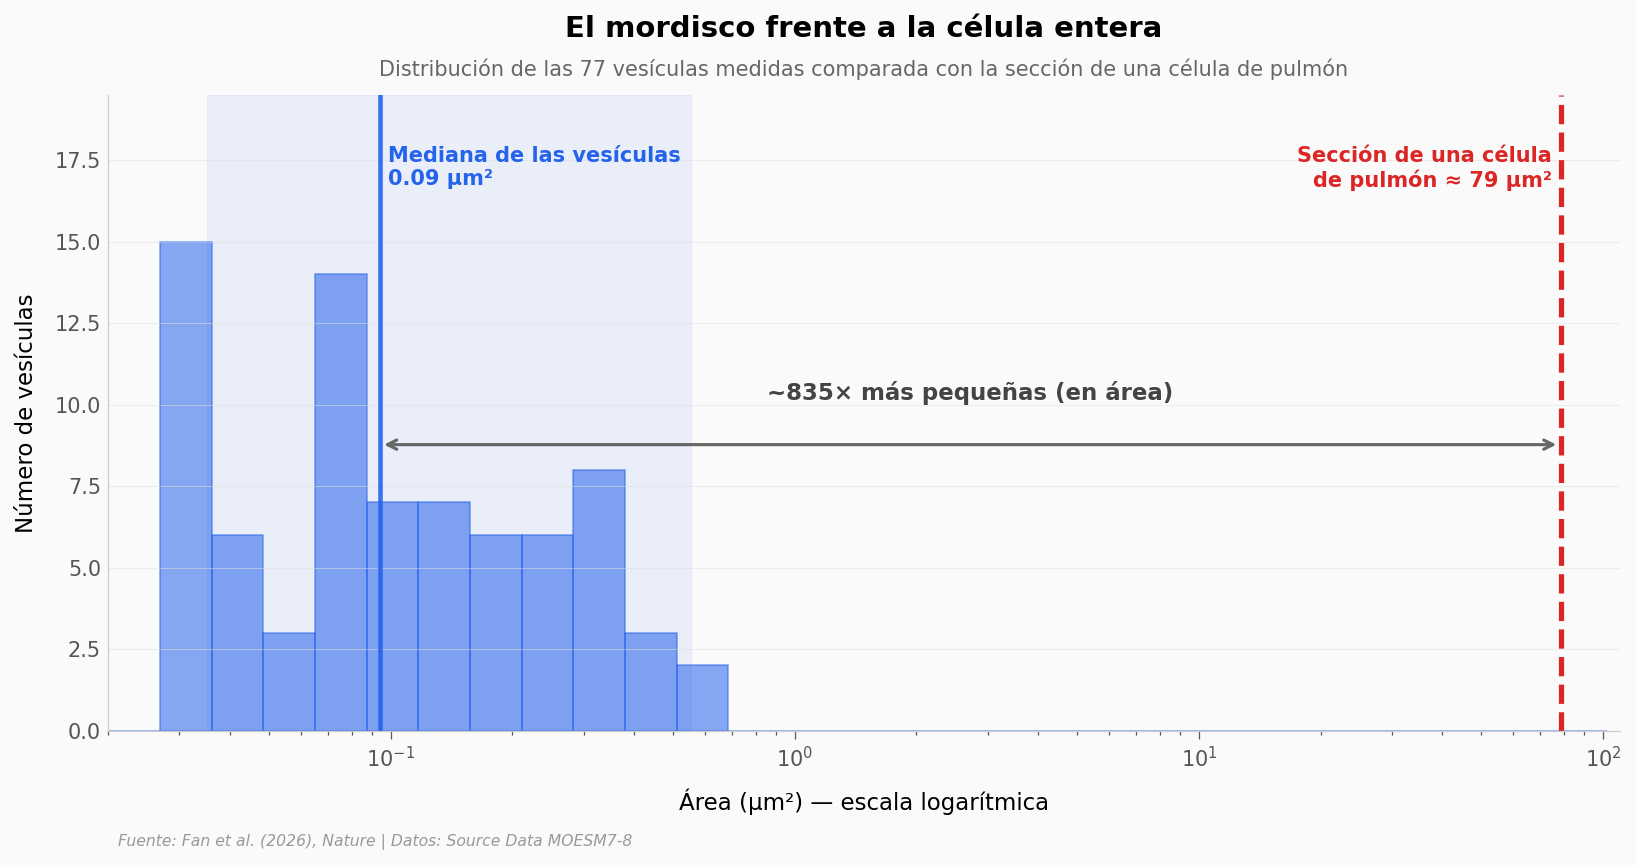

Mediana vesícula: 0.094 µm² · Sección célula entera: ~78.5 µm²
Ratio en área: 836× · Equivalente en diámetro: ~29× (la vesícula tiene ~1/28 del diámetro de la célula)


In [5]:
# Una célula del pulmón tiene ~10 µm de diámetro (sección 2D ≈ 79 µm²)
area_celula_completa_um2 = np.pi * (10/2)**2  # ≈ 78,5 µm²
ratio = area_celula_completa_um2 / median_area

fig, ax = plt.subplots(figsize=(13, 5.5))

# Histograma con bins logarítmicos para que las vesículas y la célula coexistan visualmente
log_bins = np.logspace(np.log10(0.02), np.log10(area_celula_completa_um2*1.3), 30)
n, bins, _ = ax.hist(areas, bins=log_bins, color=COLOR_DATOS, alpha=0.55,
                     edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.30
ax.set_ylim(0, y_max)
ax.set_xscale('log')
ax.set_xlim(0.02, area_celula_completa_um2*1.4)

# Banda visual para el rango de las vesículas
ax.axvspan(areas.min(), areas.max(), alpha=0.08, color=COLOR_DATOS, zorder=0)

# Línea de la mediana de vesículas
ax.axvline(median_area, color=COLOR_DATOS, linewidth=2.2, linestyle='-', alpha=0.9)
ax.text(median_area*1.05, y_max*0.92,
        f'Mediana de las vesículas\n{median_area:.2f} µm²',
        fontsize=10, color=COLOR_DATOS, fontweight='bold', va='top')

# Línea de la célula entera
ax.axvline(area_celula_completa_um2, color=COLOR_ALERTA,
           linewidth=2.5, linestyle='--')
ax.text(area_celula_completa_um2*0.95, y_max*0.92,
        f'Sección de una célula\nde pulmón ≈ {area_celula_completa_um2:.0f} µm²',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', va='top', ha='right')

# Flecha de magnitud — en log space, en el medio geométrico
geo_mid = np.sqrt(median_area * area_celula_completa_um2)
ax.annotate('', xy=(area_celula_completa_um2, y_max*0.45),
            xytext=(median_area, y_max*0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(geo_mid, y_max*0.52, f'~{int(ratio)}× más pequeñas (en área)',
        fontsize=11, fontweight='bold', color='#444444', ha='center')

ax.set_xlabel('Área (µm²) — escala logarítmica', fontsize=11)
ax.set_ylabel('Número de vesículas', fontsize=11)
ax.set_title('El mordisco frente a la célula entera',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Distribución de las {len(areas)} vesículas medidas comparada con la sección de una célula de pulmón',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escala_vesiculas_vs_celula.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mediana vesícula: {median_area:.3f} µm² · Sección célula entera: ~{area_celula_completa_um2:.1f} µm²")
print(f"Ratio en área: {ratio:.0f}× · Equivalente en diámetro: ~{np.sqrt(ratio):.0f}× (la vesícula tiene ~1/{int(np.sqrt(ratio))} del diámetro de la célula)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Los macrófagos alveolares (AM) son el tipo celular que más material vivo captura | ✅ | media = 62,7 % ± 2,5 SEM frente al siguiente más alto (IM, 33,7 % ± 3,0 SEM); n = 5 ratones, Mann-Whitney U p = 0,008 |
| El uptake en macrófagos alveolares supera ~100× al de los monocitos clásicos | ✅ | 62,7 % vs 0,55 % en cMo (ratio ≈ 114, Mann-Whitney U p = 0,008, Cohen's d ≈ 15; n = 5 ratones) |
| Las vesículas medidas son sub-micrométricas | ✅ | mediana = 0,09 µm², máximo = 0,55 µm², n = 77 vesículas de 23 células. Distribución asimétrica (la media 0,15 µm² es ~60 % mayor que la mediana) |
| El muestreo requiere contacto célula-célula | ✅ | Separar las poblaciones con transwell reduce el uptake un 77 % (n = 3 réplicas pareadas, paired t-test p ≈ 0,002 — el paper reporta P = 0,0018) |
| El proceso es no destructivo en la célula muestreada | ⚠️ | Lo soporta el paper con imaging y caspase assays — el notebook lo presenta como hallazgo sin re-verificarlo (vive fuera del Source Data MOESM7/8) |

> **Limitaciones del notebook:**
> - **n pequeños**: Fig 1c son 5 ratones; Fig 2e son 3 réplicas biológicas. Los efectos son grandes (~100×, 77 %) pero los intervalos de confianza son amplios — replicación en cohortes mayores reforzaría la magnitud exacta.
> - **Vesículas con clustering**: las 77 vesículas vienen de solo 23 células — el paper reporta la media simple sin modelar la dependencia intra-célula. La distribución asimétrica sugiere reportar mediana antes que media.
> - **Generalización a humanos**: todo el sistema está montado en ratón. El paper no aporta datos humanos directos.
> - **Cohen's d en n = 3**: para el contraste direct/transwell, el efecto es claramente grande, pero un Cohen's d puntual con n = 3 no es la métrica honesta — el paired t-test p = 0,0018 que reporta el paper sí lo es.

## Ahora tú

1. ¿Cuánta variabilidad hay entre ratones para el tipo dominante? Calcula el coeficiente de variación de AM frente al de cMo.
2. ¿Cambia la mediana de tamaño de vesícula si excluyes los extremos? Re-corta el dataset al rango 0,05–0,3 µm² y compara.
3. La condición transwell sigue dejando un ~23 % de uptake residual. ¿Es ruido de la membrana porosa o muestreo a distancia real? Mira la dispersión de las 3 réplicas.

In [6]:
# --- EXPERIMENTA AQUÍ ---

# 1) Coeficiente de variación (CV = SD / media) por tipo celular
cv = uptake.groupby('cell_type')['pct_zsgreen_positive'].agg(
    lambda x: x.std(ddof=1) / x.mean() * 100
).sort_values()
print("Coeficiente de variación (%) por tipo celular:")
print(cv.round(1).to_string())
print()

# 2) Mediana de vesículas dentro y fuera del rango más denso
denso = vesiculas[(vesiculas['area_um2'] >= 0.05) & (vesiculas['area_um2'] <= 0.3)]
print(f"Vesículas en rango denso 0,05–0,3 µm²: {len(denso)}/{len(vesiculas)}")
print(f"  Mediana del rango denso: {denso['area_um2'].median():.3f} µm²")
print(f"  Mediana global:          {vesiculas['area_um2'].median():.3f} µm²")
print()

# 3) Dispersión transwell — ¿constante o variable entre réplicas?
trans = contacto[contacto['condition'] == 'transwell']
print(f"Uptake residual en transwell:")
print(f"  rango = {trans['uptake_normalizado'].min():.3f} – {trans['uptake_normalizado'].max():.3f}")
print(f"  CV    = {trans['uptake_normalizado'].std(ddof=1) / trans['uptake_normalizado'].mean() * 100:.1f} %")

Coeficiente de variación (%) por tipo celular:
cell_type
AM       9.1
Neu     15.8
IM      19.9
cDC1    26.5
cMo     36.3
cDC2    36.7
pMo     37.2

Vesículas en rango denso 0,05–0,3 µm²: 44/77
  Mediana del rango denso: 0.112 µm²
  Mediana global:          0.094 µm²

Uptake residual en transwell:
  rango = 0.164 – 0.272
  CV    = 24.9 %


---

## Fuentes

**Paper**: [Submicrometre sampling of living cells by macrophages](https://doi.org/10.1038/s41586-026-10435-5)  
*Nature, 2026-04-29*

**Source Data** (publicados con el paper, freely accessible):  
- [Source Data Fig. 1 (MOESM7) — uptake de células mieloides en pulmón](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10435-5/MediaObjects/41586_2026_10435_MOESM7_ESM.xlsx)  
- [Source Data Fig. 2 (MOESM8) — tamaño de vesículas y contacto célula-célula](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10435-5/MediaObjects/41586_2026_10435_MOESM8_ESM.xlsx)

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
**Licencia datos originales:** Source Data MOESM7-8 publicados con el artículo bajo los términos de Springer Nature ("supplementary information freely accessible").
**Notebook por:** Ciencia a Mordiscos — abierto, reproducible, verificable.